# Multi-Platform Cosmetics Market Analysis | Cross Platform Analysis
Author: Neethu Raj 

## Project Progress

| Phase                                                |    Status   |
| ---------------------------------------------------- | :---------: |
| 1. Web Scraping – Nykaa                              | ✅ Completed |
| 2. Data Cleaning – Nykaa                             | ✅ Completed |
| 3. Exploratory Data Analysis  - Nykaa                | ✅ Completed |
| 4. SQL Business Analysis - Nykaa                     | ✅ Completed |
| 5. Power BI Dashboard - Nykaa                        | ✅ Completed |
| 6. Web Scraping – Myntra                             | ✅ Completed |
| 7. Data Cleaning – Myntraa                           | ✅ Completed |
| 8. Cross-Platform Price & Discount Comparison        | 🔄 In Progress |
| 9. Cross-Platform Power BI Dashboard                 |  ⏳ Planned  |

## Project Overview

This project analyzes the Indian online cosmetics market using product data collected from two major e-commerce platforms: Nykaa and Myntra.

The product data was scraped and cleaned separately for each platform in their respective notebooks. This notebook focuses on cross-platform analysis using the cleaned datasets.

The analysis compares Nykaa and Myntra in terms of product assortment, categories, subcategories, brands, pricing, discounts, and customer ratings to identify differences in their marketplace and promotional strategies.


## Dataset Information

This analysis uses the cleaned Nykaa and Myntra datasets prepared in their respective scraping and data-cleaning notebooks.

- **Sources:** Self-scraped product data from Nykaa and Myntra using Python and Selenium.
- **Platforms:** Nykaa and Myntra.
- **Myntra product listings:** 80,740
- **Nykaa product listings:** 23,375

Each row represents a product listing collected from one of the platforms.

The datasets contain product-level information such as:

- Product Name
- Product URL
- Category
- Sub-category
- Brand
- Original Price
- Discounted Price
- Discount Percentage
- Rating
- Rating Count
- Other platform-specific attributes

Relevant fields were standardized where necessary to enable cross-platform comparison.

## Objectives

The main objectives of this cross-platform analysis are:

- Combine the cleaned Nykaa and Myntra datasets into a common analytical dataset.
- Standardize relevant fields for meaningful cross-platform comparison.
- Compare product, category, subcategory, and brand assortment.
- Compare product pricing and discount patterns.
- Compare customer ratings and rating-related metrics.
- Examine selected relationships between product-level variables.
- Identify key differences in the assortment, pricing, promotional, and customer-response patterns of Nykaa and Myntra.
- Derive meaningful business insights from the comparison.

## Contents

1. Import Libraries
2. Load Datasets
3. Standardize Columns
4. Create Master Cross-Platform Dataset
5. Cross-Platform Analysis
   - 5.1 Platform Overview
   - 5.2 Category Analysis
   - 5.3 Subcategory Analysis
   - 5.4 Brand Analysis
   - 5.5 Price Analysis
   - 5.6 Discount Analysis
   - 5.7 Rating Analysis
   - 5.8 Relationship Analysis
6. Key Cross-Platform Findings
7. Final Conclusion

## 1. Import Libraries

The required Python libraries are imported for data manipulation, visualization, exploratory analysis, and statistical analysis.

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

## 2. Load Datasets

The cleaned Nykaa and Myntra datasets are loaded into Pandas DataFrames for cross-platform analysis.

The detailed scraping and data-cleaning processes were completed separately in the respective Nykaa and Myntra notebooks.

In [3]:
nykaa_df = pd.read_csv("nykaa_products.csv")
myntra_df = pd.read_csv("myntra_products.csv")

## 3. Standardize Columns

Before combining the datasets, the common analytical fields in the Nykaa and Myntra datasets are aligned to ensure consistency.

Column names representing the same information are standardized, while platform-specific fields that are not required for cross-platform analysis are retained only where appropriate.

Category and subcategory fields are also standardized where necessary to account for differences in naming conventions between the two platforms.

In [4]:
nykaa_df.columns

Index(['product_name', 'url', 'category', 'sub_category', 'brand',
       'discounted_price', 'original_price', 'discount_percent',
       'rating_out_of_5', 'rating_count', 'platform', 'shade_count',
       'product_id', 'sku_id', 'product_key', 'discount_percent_scraped'],
      dtype='str')

In [5]:
myntra_df.columns

Index(['product_name', 'url', 'category', 'sub_category', 'brand',
       'discounted_price', 'original_price', 'discount_percent',
       'rating_out_of_5', 'rating_count', 'platform'],
      dtype='str')

In [6]:
common_cols = [
    'product_name',
    'url',
    'category',
    'sub_category',
    'brand',
    'discounted_price',
    'original_price',
    'discount_percent',
    'rating_out_of_5',
    'rating_count',
    'platform'
]

In [7]:
nykaa_analysis = nykaa_df[common_cols].copy()
myntra_analysis = myntra_df[common_cols].copy()

## 4. Create Master Cross-Platform Dataset

The standardized Nykaa and Myntra datasets are combined to create a master dataset for cross-platform analysis.

A `platform` column is retained to identify the source platform of each product listing.

Before conducting the comparative analysis, category and subcategory names are standardized where necessary to account for differences in classification between the two platforms.

In [8]:
master_df = pd.concat(
    [nykaa_analysis, myntra_analysis],
    ignore_index=True
)

In [9]:
master_df.shape
master_df["platform"].value_counts()
master_df.head()
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104115 entries, 0 to 104114
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   product_name      104115 non-null  str    
 1   url               104115 non-null  str    
 2   category          104115 non-null  str    
 3   sub_category      104115 non-null  str    
 4   brand             104115 non-null  str    
 5   discounted_price  104115 non-null  float64
 6   original_price    104115 non-null  float64
 7   discount_percent  104115 non-null  float64
 8   rating_out_of_5   58044 non-null   float64
 9   rating_count      58044 non-null   float64
 10  platform          104115 non-null  str    
dtypes: float64(5), str(6)
memory usage: 8.7 MB


### Category Standardization

Nykaa and Myntra use different names for some equivalent product categories. These names are standardized where a clear correspondence exists so that products can be compared across platforms.

In [10]:
category_mapping = {
    "Hands Feet Care": "Hand & Foot Care",
    "Hand & Foot Care": "Hand & Foot Care"
}

In [11]:
master_df["category_standard"] = (
    master_df["category"]
    .replace(category_mapping)
)

### Subcategory Standardization

Subcategory names are standardized where equivalent product groups are represented using different names across Nykaa and Myntra.

Only mappings with a clear correspondence are applied; categories that cannot be confidently matched are retained separately.

In [12]:
subcategory_mapping = {
    "Bath salt & Bubble bath": "Bath Accessories",
    "Bath salts": "Bath Accessories",
    "Bath Salts" : "Bath Accessories",
    "Bath Accessories" : "Bath Accessories",
    "Under Eye Cream & Serum" : "Under Eye Cream & Serum",
    "Under Eye Creams & Serums" : "Under Eye Cream & Serum",
    "Body Lotion" : "Body Lotion",
    "Body lotions" : "Body Lotion",
    "Lipstick" : "Bullet Lipstick",
    "Bullet Lipstick" : "Bullet Lipstick",
    "Cleanser" : "Face Wash & Cleanser", 
    "Face Wash & Cleanser" : "Face Wash & Cleanser",
    "Face Wash" : "Face Wash & Cleanser",
    "Face Compact" : "Face Compact", 
    "Compact" : "Face Compact",
    "Face Bronzer" : "Face Bronzer",
    "Bronzer" : "Face Bronzer",
    "Concealer" : "Face Concealer",
    "Face Concealer" : "Face Concealer",
    "Contour" : "Face Contour", 
    "Face Contour" : "Face Contour",
    "Face Moisturizer" : "Face Moisturizer",
    "Day Cream/ Face Moisterizer" : "Face Moisturizer", 
    "Eye Kajal" : "Kajal",
    "Kajal" : "Kajal",
    "Eye Liner" : "Eyeliner",
    "Eye Mascara" : "Mascara",
    "Mascara" : "Mascara",
    "Eyeshadow" : "Eyeshadow Palette", 
    "Eyeshadow Palette" : "Eyeshadow Palette",
    "Face Highlighter" : "Face Highlighter",
    "Highlighter": "Face Highlighter", 
    "Face Masks" : "Mask & Peel",
    "Mask & Peel" : "Mask & Peel", 
    "Face Scrub & Exfoliator" : "Face Scrub & Exfoliator",
    "Face Scrub" : "Face Scrub & Exfoliator", 
    "Face Oil" : "Face Oil",
    "Facial Oil" : "Face Oil",
    "Hand Cream" : "Hand Cream", 
    "Hand Creams" : "Hand Cream", 
    "Lip Mask" : "Lip Mask",
    "Lip Masks" : "Lip Mask", 
    "Lip Scrub" : "Lip Scrub",
    "Lip Scrubs" : "Lip Scrub", 
    "Lip Tint & Lip Stain" : "Lip Tint & Lip Stain",
    "Lip Tint" : "Lip Tint & Lip Stain", 
    "Lip Stain" : "Lip Tint & Lip Stain", 
    "Multi-Functional Makeup Palette" : "Multi-Functional Makeup Palette", 
    "Face Palette" : "Multi-Functional Makeup Palette",
    "Multi-Functional Makeup Palettes" : "Multi-Functional Makeup Palette",
    "Serum & Gel" : "Serum, Essence & Gel",
    "Serums & Essence" : "Serum, Essence & Gel", 
    "Soap" : "Soap", 
    "Soaps" : "Soap", 
}

In [13]:
master_df["subcategory_standard"] = (
    master_df["sub_category"]
    .replace(subcategory_mapping)
)

In [14]:
# pd.set_option('display.max_rows', None)
# pd.crosstab(
#     master_df["subcategory_standard"],
#     master_df["platform"]
# )

### Export Master Dataset

The consolidated dataset is exported for use in subsequent analysis and visualization.

In [15]:
master_df.to_csv('beauty_products_master.csv',index=False)

## 5. Cross-Platform Analysis

The master dataset is analyzed to compare Nykaa and Myntra across product assortment, categories, subcategories, brands, pricing, discounts, and customer ratings.

Where the platforms use different category or subcategory names, standardized fields are used to make the comparisons more consistent.

### 5.1 Platform Overview

The platform overview compares the overall size and structure of the product datasets.

The comparison includes:

- Product count
- Category count
- Subcategory count
- Brand count


In [16]:
master_df.groupby('platform').agg(
    
           product_count= ('product_name' , 'count'),
           category_count = ('category_standard' , 'nunique'),
           subcategory_count = ( 'subcategory_standard' , 'nunique'),
           brand_count =('brand' , 'nunique')

    )

,product_count,category_count,subcategory_count,brand_count
platform,,,,
Myntra,80740,10,51,2853
Nykaa,23375,11,74,893


#### Observations

Myntra has a substantially larger product assortment in the collected dataset than Nykaa. It also contains a larger number of brands.

The two platforms differ in their category and subcategory structures. Some product groups use different naming conventions or levels of classification across the platforms. Therefore, standardized category and subcategory fields are used where appropriate for meaningful comparison.

### 5.2 Category Analysis

The category distribution is analyzed to compare the composition of product assortments across Nykaa and Myntra.

Both absolute product counts and percentage shares are examined because the total number of products collected from the two platforms differs substantially.

Standardized category names are used where equivalent categories were identified across the platforms.


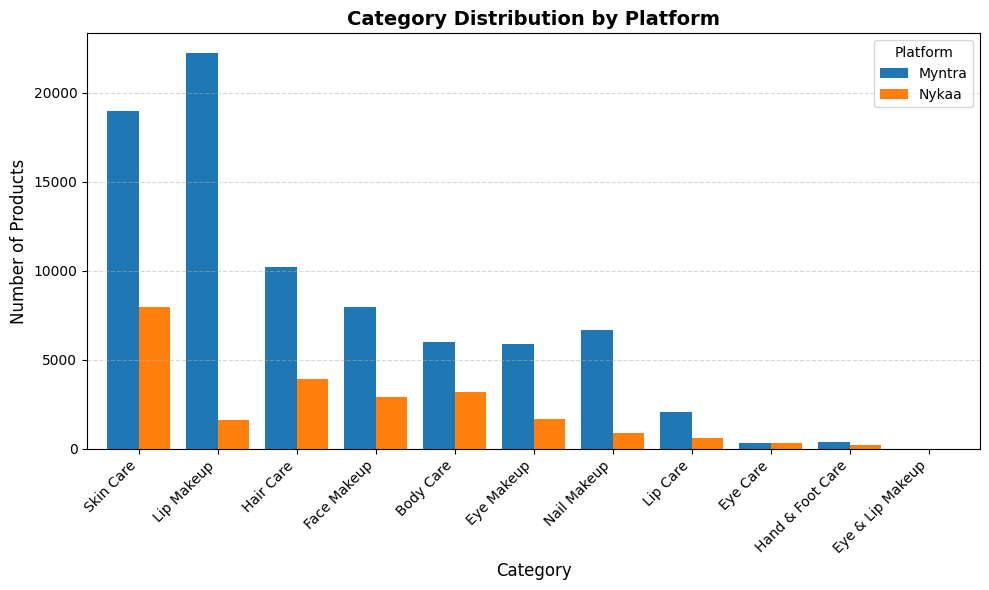

In [35]:
cat_comparison = (
    master_df
        .groupby(['category_standard', 'platform'])
        .size()
        .unstack(fill_value=0)
)

cat_comparison['Total'] = cat_comparison.sum(axis=1)
cat_comparison = (
    cat_comparison
        .sort_values(by='Total', ascending=False)
        .drop(columns='Total')
)


cat_comparison.plot(kind='bar', figsize=(10, 6), width=0.8)


plt.title(
    'Category Distribution by Platform', 
          fontsize=14, 
          fontweight='bold'
)
plt.xlabel(
    'Category', 
    fontsize=12
)
plt.ylabel(
    'Number of Products',
    fontsize=12
)
plt.xticks(
    rotation=45, 
    ha='right'
)
plt.grid(
    axis='y', 
    linestyle='--', 
    alpha=0.5
)
plt.legend(
    title='Platform', 
    fontsize=10
)
plt.tight_layout()

plt.show()

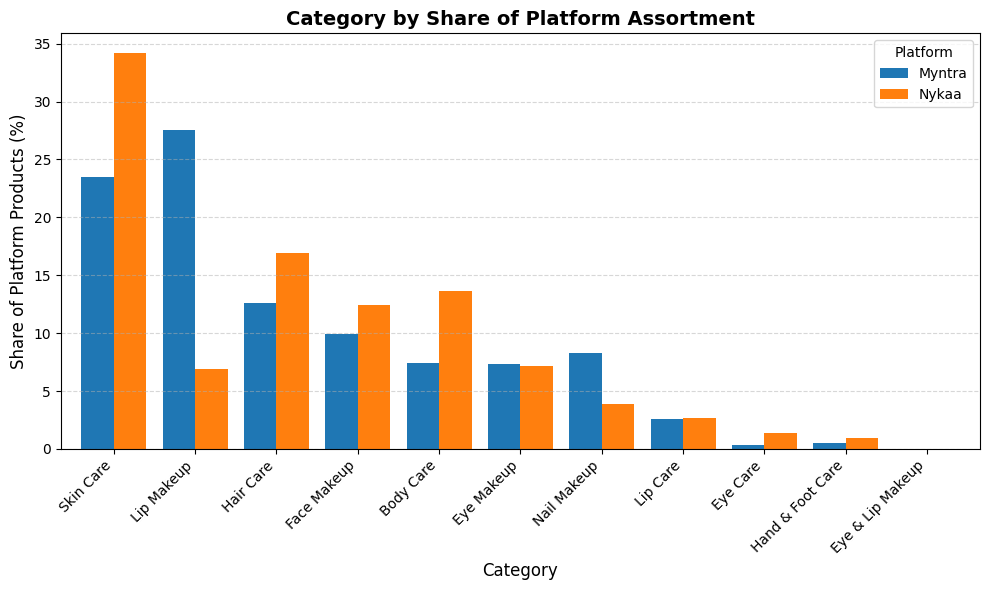

In [18]:
# 1. Count products by standardized category and platform
cat_share = (
    master_df
        .groupby(['category_standard', 'platform'])
        .size()
        .unstack(fill_value=0)
)

# 2. Calculate total products on each platform
platform_totals = master_df['platform'].value_counts()

# 3. Convert counts to percentage of each platform's product assortment
cat_share['Myntra'] = (
    cat_share['Myntra'] / platform_totals['Myntra'] * 100
)

cat_share['Nykaa'] = (
    cat_share['Nykaa'] / platform_totals['Nykaa'] * 100
)

# 4. Sort by combined share
cat_share['Total'] = cat_share['Myntra'] + cat_share['Nykaa']

cat_share = (
    cat_share
    .sort_values('Total', ascending=False)
    .drop(columns='Total')
)

cat_share.plot(kind='bar', figsize=(10, 6), width=0.8)


plt.title(
    'Category by Share of Platform Assortment', 
          fontsize=14, 
          fontweight='bold'
)
plt.xlabel(
    'Category', 
    fontsize=12
)
plt.ylabel(
    'Share of Platform Products (%)',
    fontsize=12
)
plt.xticks(
    rotation=45, 
    ha='right'
)
plt.grid(
    axis='y', 
    linestyle='--', 
    alpha=0.5
)
plt.legend(
    title='Platform', 
    fontsize=10
)
plt.tight_layout()

plt.show()

#### Observations

Nykaa has its largest assortment share in Skin Care, accounting for approximately 34% of its products. Myntra has a much larger concentration in Lip Makeup, accounting for approximately 27.5% of its assortment.

The category shares also show differences in assortment emphasis across the two platforms, with Myntra showing stronger representation in Lip Makeup and Nail Makeup, while Nykaa has relatively higher shares in several skincare and personal-care categories.

### 5.3 Subcategory Analysis

The subcategory analysis provides a more detailed comparison of the product assortment on Nykaa and Myntra.

Because the platforms use different subcategory naming conventions, standardized subcategory names are used where clear mappings are available.

Both product counts and percentage shares are examined, with percentage share providing a more comparable measure given the different dataset sizes.


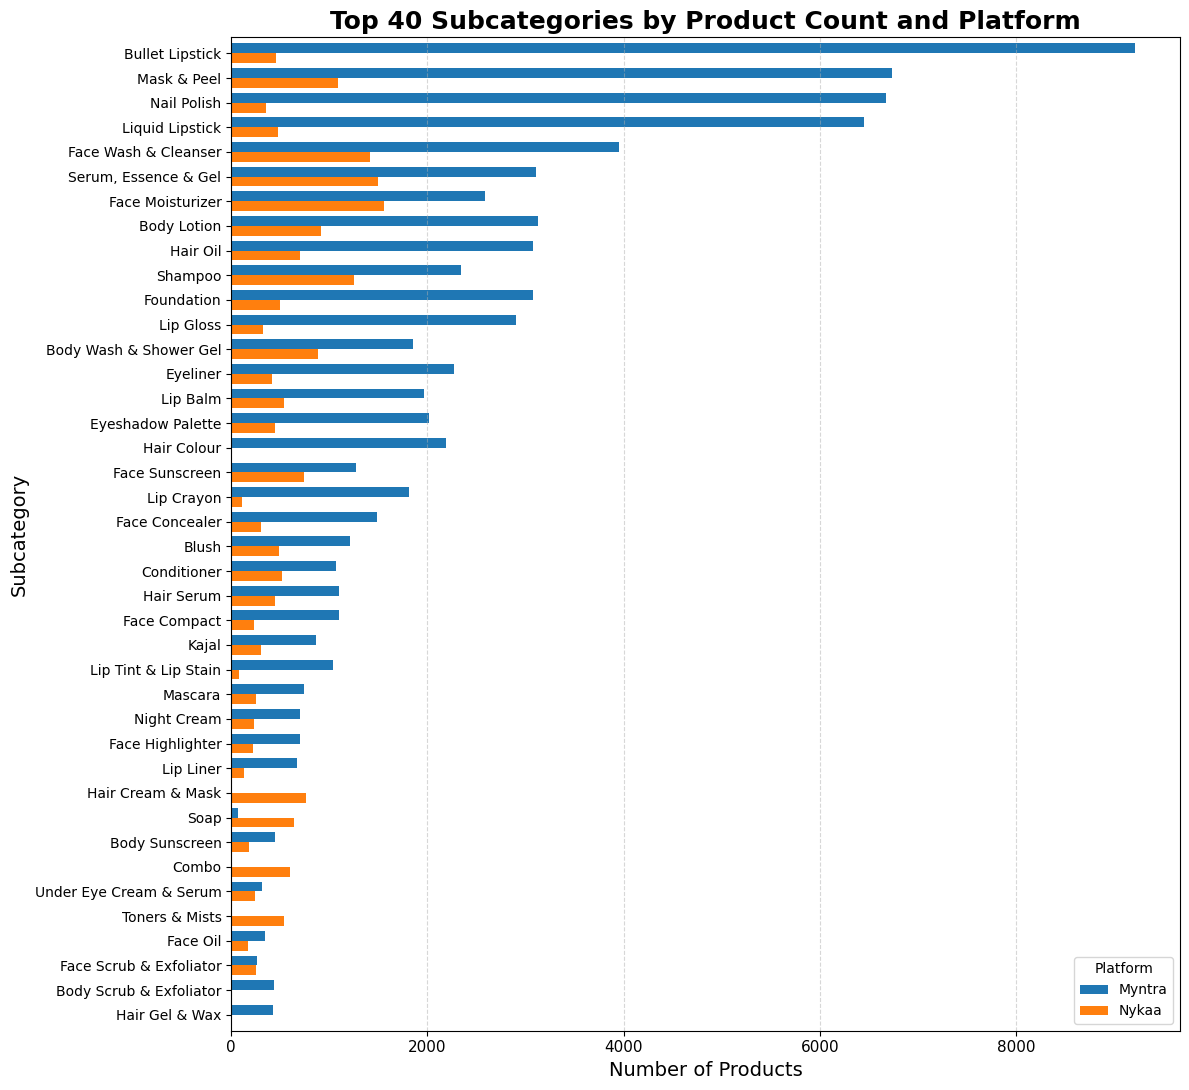

In [19]:
# 1. Group, count, and reshape the data
subcat_distribution = (
    master_df
    .groupby(['subcategory_standard', 'platform'])
    .size()
    .unstack(fill_value=0)
)

# 2. Sort by total product count across both platforms
subcat_distribution['Total'] = subcat_distribution.sum(axis=1)

subcat_distribution = (
    subcat_distribution
    .sort_values(by='Total', ascending=False)
    .drop(columns='Total')
)

# 3. Select top 40 subcategories
top_40 = subcat_distribution.head(40)

# 4. Create grouped horizontal bar plot
ax = top_40.plot(
    kind='barh',
    figsize=(12, 11),
    width=0.8
)

# 5. Put largest category at the top
ax.invert_yaxis()

# 6. Customize
plt.title(
    'Top 40 Subcategories by Product Count and Platform',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Number of Products', fontsize=14)
plt.ylabel('Subcategory', fontsize=14)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.legend(
    title='Platform',
    fontsize=10
)

plt.tight_layout()
plt.show()

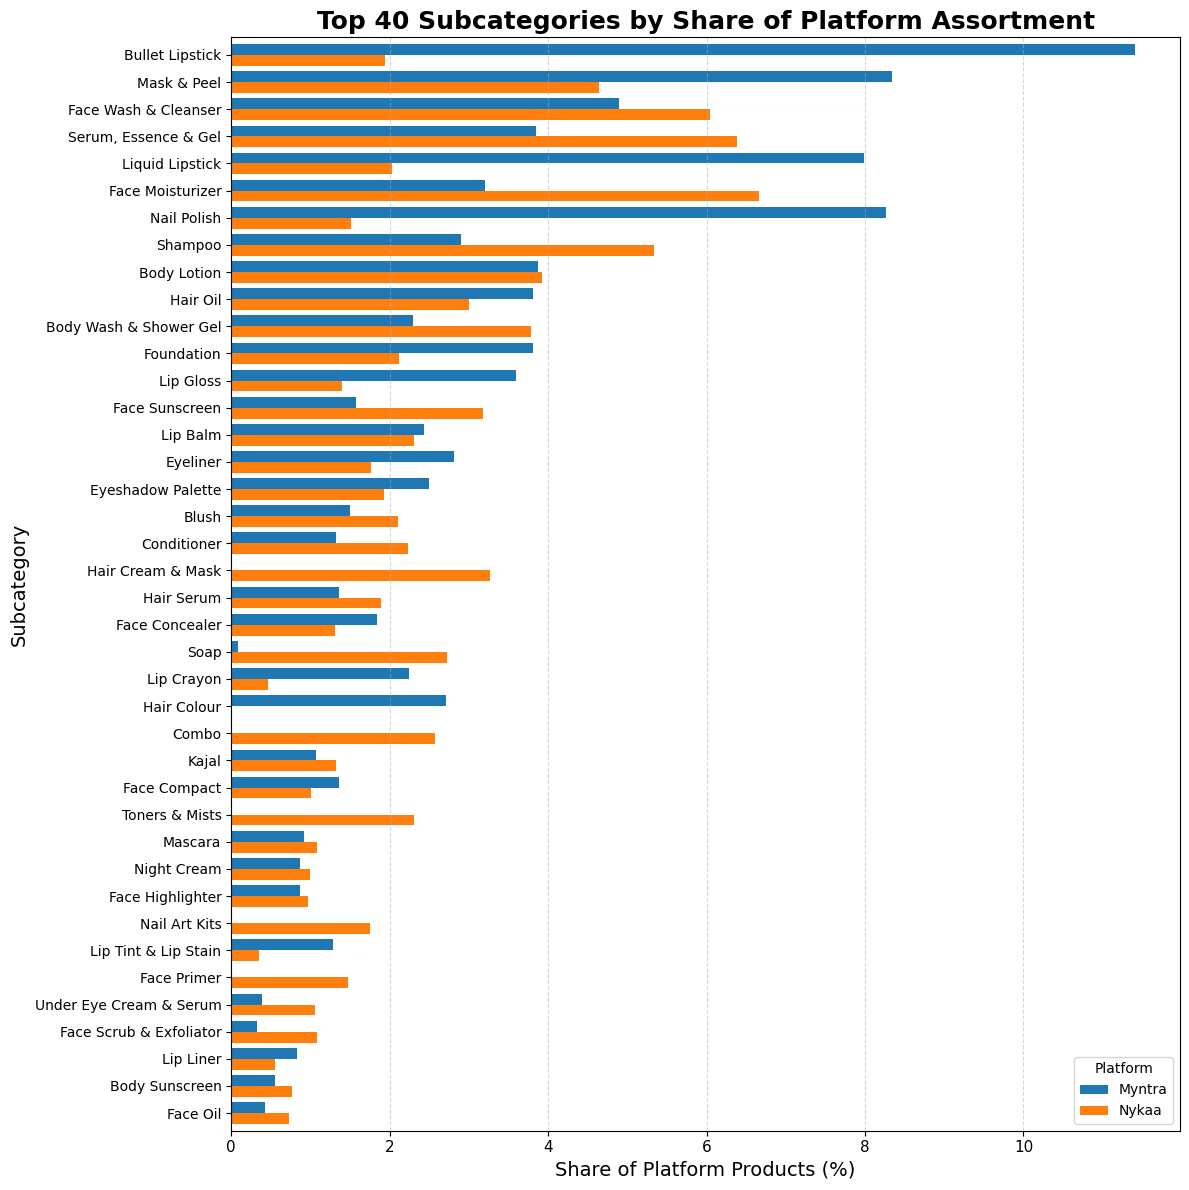

In [20]:
# 1. Count products by standardized subcategory and platform
subcat_share = (
    master_df
    .groupby(['subcategory_standard', 'platform'])
    .size()
    .unstack(fill_value=0)
)

# 2. Calculate total products on each platform
platform_totals = master_df['platform'].value_counts()

# 3. Convert counts to percentage of each platform's product assortment
subcat_share['Myntra'] = (
    subcat_share['Myntra'] / platform_totals['Myntra'] * 100
)

subcat_share['Nykaa'] = (
    subcat_share['Nykaa'] / platform_totals['Nykaa'] * 100
)

# 4. Sort by combined share
subcat_share['Total'] = subcat_share['Myntra'] + subcat_share['Nykaa']

subcat_share = (
    subcat_share
    .sort_values('Total', ascending=False)
    .drop(columns='Total')
)

# 5. Select top 40 subcategories
top_40_share = subcat_share.head(40)

# 6. Plot
ax = top_40_share.plot(
    kind='barh',
    figsize=(12, 12),
    width=0.8
)

ax.invert_yaxis()

plt.title(
    'Top 40 Subcategories by Share of Platform Assortment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Share of Platform Products (%)',
    fontsize=14
)

plt.ylabel(
    'Subcategory',
    fontsize=14
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.legend(
    title='Platform',
    fontsize=10
)

plt.tight_layout()
plt.show()

#### Observations

The subcategory distribution shows substantial differences in assortment emphasis between the platforms.

Myntra has particularly high representation in subcategories such as Bullet Lipstick, Liquid Lipstick, and Nail Polish. Nykaa has relatively higher representation in several skincare and personal-care subcategories, including Face Moisturizer, Serum, Essence & Gel, and Shampoo.

These differences indicate that the two platforms have distinct product-mix priorities within the cosmetics market.

### 5.4 Brand Analysis

The brand analysis compares the breadth and distribution of brands represented on Nykaa and Myntra.

Because the number of brands is large, the visualization focuses on the leading brands by product count rather than displaying the complete brand distribution.


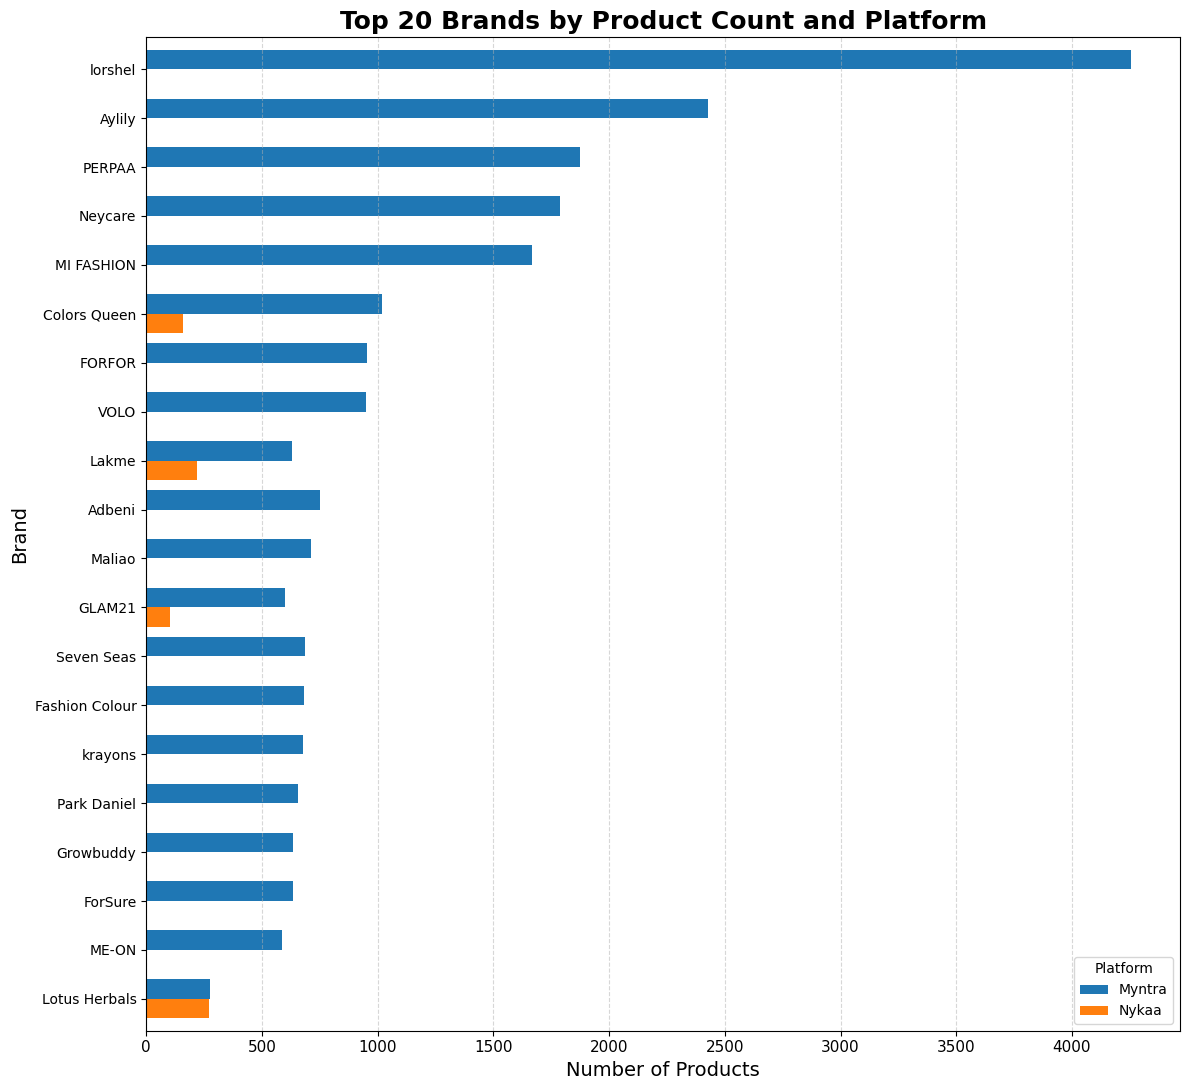

In [21]:
# 1. Group, count, and reshape the data
brand_distribution = (
    master_df
    .groupby(['brand', 'platform'])
    .size()
    .unstack(fill_value=0)
)

# 2. Sort by total product count across both platforms
brand_distribution['Total'] = brand_distribution.sum(axis=1)

brand_distribution = (
    brand_distribution
    .sort_values(by='Total', ascending=False)
    .drop(columns='Total')
)

# 3. Select top 20 subcategories
top_20 = brand_distribution.head(20)

# 4. Create grouped horizontal bar plot
ax = top_20.plot(
    kind='barh',
    figsize=(12, 11),
    width=0.8
)

# 5. Put largest category at the top
ax.invert_yaxis()

# 6. Customize
plt.title(
    'Top 20 Brands by Product Count and Platform',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Number of Products', fontsize=14)
plt.ylabel('Brand', fontsize=14)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.legend(
    title='Platform',
    fontsize=10
)

plt.tight_layout()
plt.show()

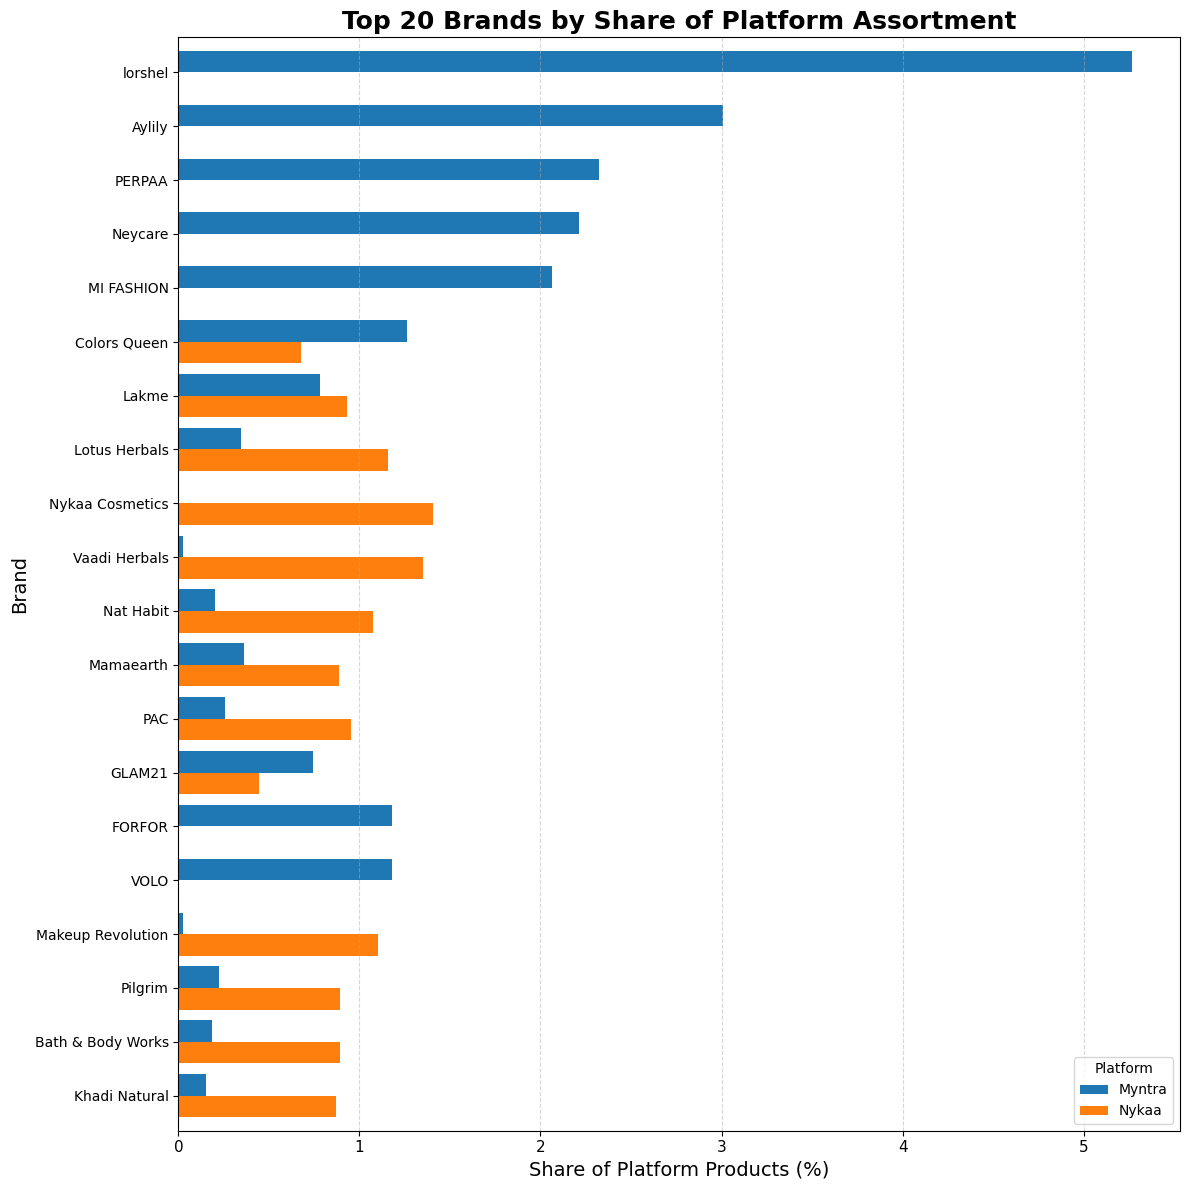

In [22]:
# 1. Count products by standardized subcategory and platform
brand_share = (
    master_df
    .groupby(['brand', 'platform'])
    .size()
    .unstack(fill_value=0)
)

# 2. Calculate total products on each platform
platform_totals = master_df['platform'].value_counts()

# 3. Convert counts to percentage of each platform's product assortment
brand_share['Myntra'] = (
    brand_share['Myntra'] / platform_totals['Myntra'] * 100
)

brand_share['Nykaa'] = (
    brand_share['Nykaa'] / platform_totals['Nykaa'] * 100
)

# 4. Sort by combined share
brand_share['Total'] = brand_share['Myntra'] + brand_share['Nykaa']

brand_share = (
    brand_share
    .sort_values('Total', ascending=False)
    .drop(columns='Total')
)

brand_share = brand_share[brand_share.index != 'Unknown']

# 5. Select top 20 subcategories
top_20_share = brand_share.head(20)

# 6. Plot
ax = top_20_share.plot(
    kind='barh',
    figsize=(12, 12),
    width=0.8
)

ax.invert_yaxis()

plt.title(
    'Top 20 Brands by Share of Platform Assortment',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Share of Platform Products (%)',
    fontsize=14
)

plt.ylabel(
    'Brand',
    fontsize=14
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.legend(
    title='Platform',
    fontsize=10
)

plt.tight_layout()
plt.show()


#### Observations

The brand distribution differs substantially between the two platforms.

Several brands account for a relatively large share of Myntra's collected product assortment, with Lorshel representing more than 5% of the products. Nykaa's leading brands include Nykaa Cosmetics, Vaadi Herbals, and Lotus Herbals.

The difference in leading-brand representation suggests that the platforms have different brand mixes within the collected assortment.

### 5.5 Price Analysis

Product prices are analyzed to compare the price positioning of Nykaa and Myntra.

The analysis examines the distribution of product prices and compares typical product prices across the two platforms.

Median price is used as an important comparison metric because product prices are highly skewed and can be affected by a relatively small number of expensive products.


#### Price Distribution

Product prices are highly right-skewed, with a small number of very expensive products.

To make the distribution easier to visualize, the 99th percentile is used as an upper visualization limit. This affects only the visualization and does not remove products from the master dataset.

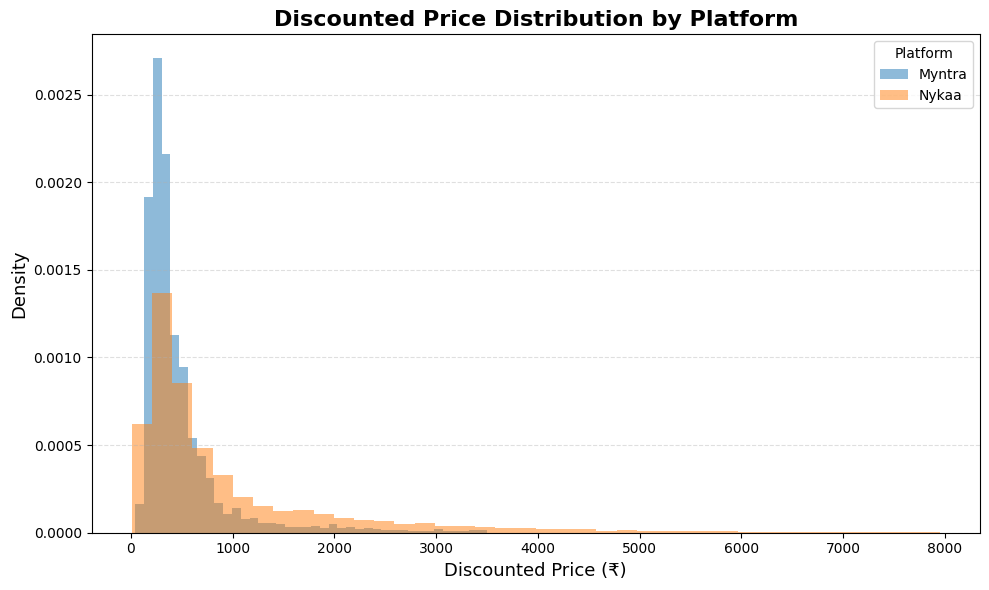

In [23]:
# Remove missing prices
price_df = master_df[
    master_df['discounted_price'].notna()
].copy()

# Find the 99th percentile separately for each platform
myntra_99 = price_df.loc[
    price_df['platform'] == 'Myntra',
    'discounted_price'
].quantile(0.99)

nykaa_99 = price_df.loc[
    price_df['platform'] == 'Nykaa',
    'discounted_price'
].quantile(0.99)

# Keep prices within each platform's 99th percentile
myntra_prices = price_df.loc[
    (price_df['platform'] == 'Myntra') &
    (price_df['discounted_price'] <= myntra_99),
    'discounted_price'
]

nykaa_prices = price_df.loc[
    (price_df['platform'] == 'Nykaa') &
    (price_df['discounted_price'] <= nykaa_99),
    'discounted_price'
]

# Plot normalized histograms
plt.figure(figsize=(10, 6))

plt.hist(
    myntra_prices,
    bins=40,
    density=True,
    alpha=0.5,
    label='Myntra'
)

plt.hist(
    nykaa_prices,
    bins=40,
    density=True,
    alpha=0.5,
    label='Nykaa'
)

plt.title(
    'Discounted Price Distribution by Platform',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Discounted Price (₹)', fontsize=13)
plt.ylabel('Density', fontsize=13)

plt.legend(title='Platform')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### Observations

Both platforms show strongly right-skewed discounted-price distributions, with most products concentrated at relatively lower prices and a smaller number of products extending into higher price ranges.

Myntra shows greater concentration in the lower-price range, while Nykaa has a broader distribution extending further into higher price ranges.

The substantial overlap between the distributions indicates that both platforms offer products across similar lower-price ranges, although their overall price positioning differs.


### Price statistics

In [24]:
master_df.groupby('platform')['discounted_price'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).round(2)

,count,mean,median,min,max,std
platform,,,,,,
Myntra,80740,532.74,340.0,43.0,42150.0,812.83
Nykaa,23375,1139.44,525.0,10.0,174500.0,2907.50


#### Observations

Nykaa has a higher typical product price than Myntra.

The median discounted price is:

- **Myntra:** ₹340
- **Nykaa:** ₹525

The median is used as the primary comparison because the price distributions are strongly right-skewed and are influenced by a smaller number of high-priced products.

### Category-Level Price Comparison

Median discounted prices are compared across standardized categories that are represented on both platforms.

Restricting the comparison to categories available on both platforms provides a more direct comparison of price positioning within comparable product groups.

In [25]:
category_price = (
    master_df
    .groupby(['category_standard', 'platform'])['discounted_price']
    .median()
    .unstack()
)

category_price

platform,Myntra,Nykaa
category_standard,,
Body Care,381.0,399.0
Eye & Lip Makeup,NaN,1678.0
Eye Care,734.5,900.0
Eye Makeup,305.0,541.0
Face Makeup,419.0,735.0
Hair Care,397.0,594.0
Hand & Foot Care,399.0,399.0
Lip Care,333.0,362.5
Lip Makeup,340.0,629.0


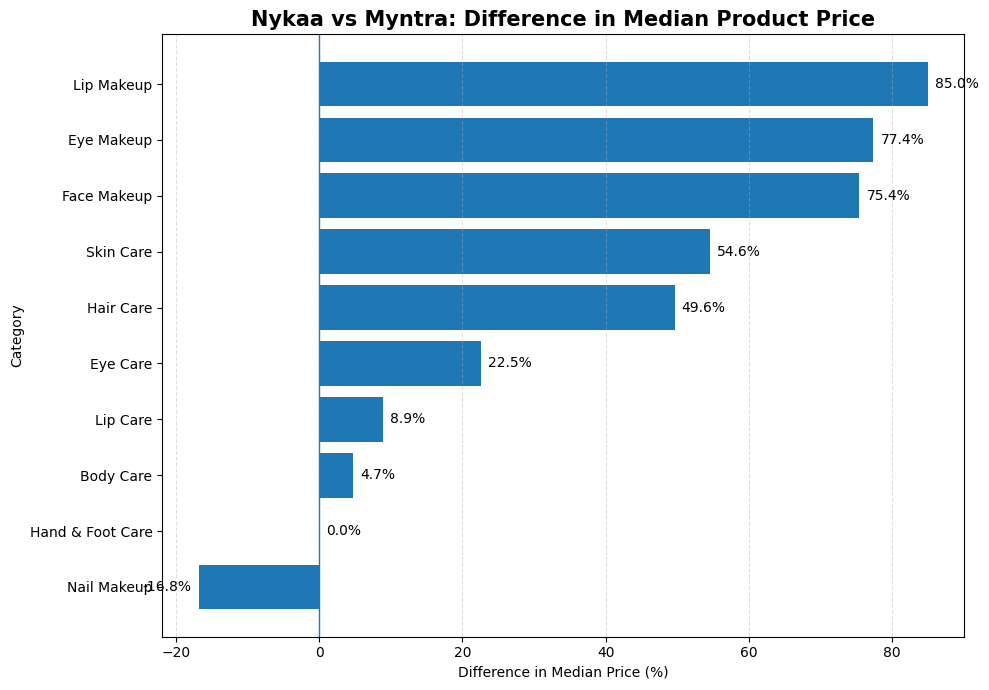

In [26]:
# Keep categories available on both platforms
price_comparison = category_price.dropna(subset=['Myntra', 'Nykaa']).copy()

# Calculate percentage difference
price_comparison['difference_percent'] = (
    (price_comparison['Nykaa'] - price_comparison['Myntra'])
    / price_comparison['Myntra']
) * 100

# Sort
price_comparison = price_comparison.sort_values(
    'difference_percent'
)

# Plot
plt.figure(figsize=(10, 7))

bars = plt.barh(
    price_comparison.index,
    price_comparison['difference_percent']
)

plt.axvline(0, linewidth=1)

plt.title(
    'Nykaa vs Myntra: Difference in Median Product Price',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Difference in Median Price (%)')
plt.ylabel('Category')

# Add percentage labels
for bar in bars:
    value = bar.get_width()

    if value >= 0:
        plt.text(
            value + 1,
            bar.get_y() + bar.get_height()/2,
            f'{value:.1f}%',
            va='center'
        )
    else:
        plt.text(
            value - 1,
            bar.get_y() + bar.get_height()/2,
            f'{value:.1f}%',
            va='center',
            ha='right'
        )

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#### Observations

Median discounted prices differ across categories, with some categories showing substantially higher typical prices on Nykaa and others showing smaller differences.

The comparison is restricted to standardized categories represented on both platforms, making the results more directly comparable.

### 5.6 Discount Analysis

Discount percentages are analyzed to compare the promotional pricing strategies of Nykaa and Myntra.

The analysis includes overall discount statistics and the distribution of products across discount bands.

In [27]:
master_df.groupby('platform')['discount_percent'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
).round(2)

,count,mean,median,min,max,std
platform,,,,,,
Myntra,80740,27.49,24.7,0.0,89.9,23.81
Nykaa,23375,13.78,12.0,0.0,83.0,13.11


In [28]:
bins = [-0.1, 0, 10, 20, 30, 40, 50, 100]

labels = [
    'No discount',
    '1–10%',
    '11–20%',
    '21–30%',
    '31–40%',
    '41–50%',
    '>50%'
]

master_df['discount_band'] = pd.cut(
    master_df['discount_percent'],
    bins=bins,
    labels=labels
)

In [29]:
discount_distribution = (pd.crosstab(
    master_df['platform'],
    master_df['discount_band'],
    normalize='index'
) * 100).round(1)

#discount_distribution.round(1)
discount_distribution

discount_band,No discount,1–10%,11–20%,21–30%,31–40%,41–50%,>50%
platform,,,,,,,
Myntra,23.5,7.8,14.1,11.5,14.0,7.4,21.7
Nykaa,27.0,22.4,28.1,13.6,5.4,2.1,1.4


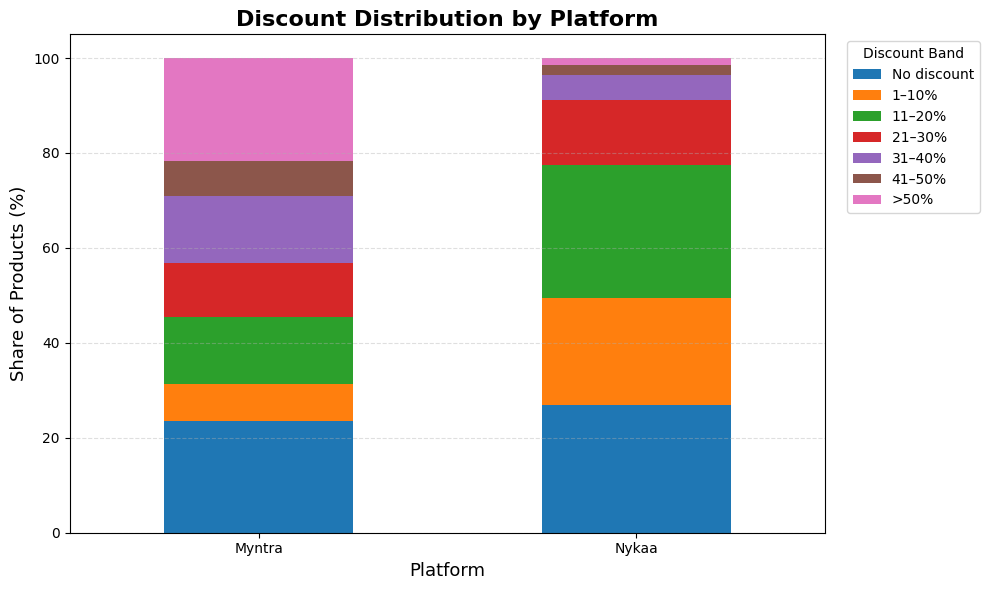

In [30]:
discount_distribution.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    'Discount Distribution by Platform',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Platform', fontsize=13)
plt.ylabel('Share of Products (%)', fontsize=13)

plt.xticks(rotation=0)

plt.legend(
    title='Discount Band',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### Observations

Myntra shows a substantially more aggressive discounting pattern. Approximately 21.7% of Myntra products fall into the >50% discount band, compared with approximately 1.4% on Nykaa.

In contrast, Nykaa's discounts are concentrated mainly in the 1–20% range.

This indicates a clear difference in the promotional discount structure observed across the two platforms.

### 5.7 Rating Analysis

Customer ratings are analyzed to compare the overall rating levels of products listed on Nykaa and Myntra.

The comparison considers the number of rated products, mean rating, median rating, and variation in ratings.

Because the two platforms use different rating granularities, detailed rating comparisons should be interpreted cautiously.

In [31]:
master_df.groupby('platform')['rating_out_of_5'].agg(
    ['mean', 'median', 'min', 'max', 'std']
).round(2)

,mean,median,min,max,std
platform,,,,,
Myntra,4.26,4.4,1.0,5.0,0.43
Nykaa,4.25,4.0,1.0,5.0,0.59


#### Observations

The average product ratings are very similar across the two platforms.

- **Myntra:** 4.26
- **Nykaa:** 4.25

This indicates little difference in overall average product ratings between the platforms.

However, the platforms use different rating granularities, with Nykaa primarily displaying whole-star ratings. Therefore, detailed comparisons of rating distributions should be interpreted cautiously.

### 5.8 Relationship Analysis

Selected relationships between product-level variables are examined to determine whether variables such as rating, rating count, price, and discount percentage are associated with one another.

#### Rating vs Rating Count


In [32]:
rating_count_corr = (
    master_df
    .groupby('platform')
    .apply(lambda x: x['rating_out_of_5'].corr(x['rating_count']))
)

rating_count_corr.round(3)

platform
Myntra    0.068
Nykaa     0.015
dtype: float64

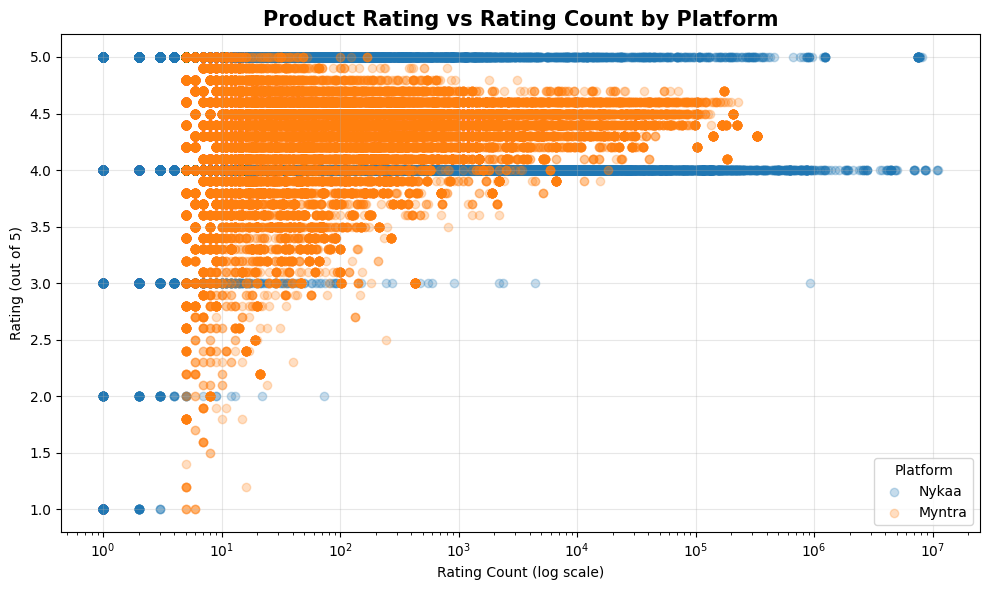

In [33]:
plt.figure(figsize=(10, 6))

for platform in master_df['platform'].dropna().unique():
    data = master_df[master_df['platform'] == platform].dropna(
        subset=['rating_out_of_5', 'rating_count']
    )

    plt.scatter(
        data['rating_count'],
        data['rating_out_of_5'],
        alpha=0.25,
        label=platform
    )

plt.xscale('log')

plt.title(
    'Product Rating vs Rating Count by Platform',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Rating Count (log scale)')
plt.ylabel('Rating (out of 5)')
plt.legend(title='Platform')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Observations

The relationship between rating and rating count is very weak on both platforms.

The Pearson correlation is **0.068 for Myntra** and **0.015 for Nykaa**, indicating almost no linear relationship between the number of ratings and the product rating.

Therefore, products with more customer ratings do not necessarily have higher ratings in the collected data.

### Price vs Discount

In [34]:
price_discount_corr = (
    master_df
    .groupby('platform')
    .apply(
        lambda x: x['original_price'].corr(x['discount_percent'])
    )
)

price_discount_corr.round(3)

platform
Myntra    0.014
Nykaa    -0.119
dtype: float64

#### Observations

Original price and discount percentage show almost no linear relationship on Myntra (r = 0.014) and a weak negative relationship on Nykaa (r = -0.119).

This suggests that higher-priced products do not consistently receive higher percentage discounts.

## 6. Key Cross-Platform Findings
### Product Assortment
Myntra has a substantially larger product assortment and a broader brand presence in the collected dataset than Nykaa.

### Assortment Structure
The two platforms have noticeably different category and subcategory structures. Standardization was necessary to make comparable product groups easier to analyze.

### Price Positioning
Myntra has a lower median discounted price (₹340) than Nykaa (₹525), indicating a higher typical price position on Nykaa.

### Discount Strategy
Myntra follows a substantially more aggressive discounting strategy. Approximately 21.7% of its products fall into the >50% discount band, compared with approximately 1.4% on Nykaa.

### Customer Ratings
Average ratings are almost identical between the platforms: 4.26 on Myntra and 4.25 on Nykaa.

### Relationships
Rating count has almost no linear relationship with rating on either platform. Original price also shows little relationship with discount percentage.

## 7. Final Conclusion

The cross-platform analysis reveals clear differences between Nykaa and Myntra in product assortment, pricing, and discounting strategies.

Myntra has a substantially larger product and brand assortment in the collected dataset and follows a more aggressive discounting strategy. Nykaa has a higher median product price and its discounts are concentrated more heavily in the low-to-moderate range.

Despite these differences, average product ratings are almost identical across the two platforms. The relationship analyses also indicate that rating count is not strongly associated with product rating, while original price is not strongly associated with discount percentage.

Overall, the findings suggest that the collected data suggests that Myntra has a broader assortment and deeper promotional discounts, whereas Nykaa shows higher typical prices and more moderate discounting.